# ****Library Import****

In [ ]:
import os                                                                             # for dictionary and file operations
import numpy as np                                                                    # For Mathematical Operations
import random                                                                         # For random value generation
import matplotlib.pyplot as plt                                                       # Data Viualization
import kagglehub                                                                      # For Data Importation
import tensorflow as tf                                                               # Import tensorflow
from PIL import Image, ImageEnhance                                                   # Image processing and enhancing
from tensorflow.keras.preprocessing.image import load_img                             # Image Loading
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAvgPool2D   # Keras layers for CNN
from tensorflow.keras.models import Sequential                                        # Model type in CNN
from tensorflow.keras.optimizers import AdamW                                         # Adam with corrected weight decay
from tensorflow.keras.callbacks import EarlyStopping                                  # EarlyStopping to avoid overfitting
from tensorflow.keras.applications import VGG16                                       # Pretrained model VGG16
from tensorflow.keras import mixed_precision
from sklearn.utils import shuffle                                                     # Shuffle Data for better detection
import keras

# Utilities
import warnings
warnings.filterwarnings('ignore')

seed = 42

keras.utils.set_random_seed(seed)

# ****Data Import****

In [ ]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

# Make Directory for training and testing data
train = os.path.join(path, 'Training')
test = os.path.join(path, 'Testing')

# Load and Shuffle Training Images
train_path = []
train_label = []

for labels in os.listdir(train):
  for image in os.listdir(os.path.join(train, labels)):
    train_path.append(os.path.join(train, labels, image))
    train_label.append(labels)

train_path, train_label = shuffle(train_path, train_label)

# Load and Shuffle Testing Images
test_path = []
test_labels = []

for label in os.listdir(test):
  for image in os.listdir(os.path.join(test, label)):
    test_path.append(os.path.join(test, label, image))
    test_labels.append(label)

test_path, test_labels = shuffle(test_path, test_labels)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


# ****Data Visualization****

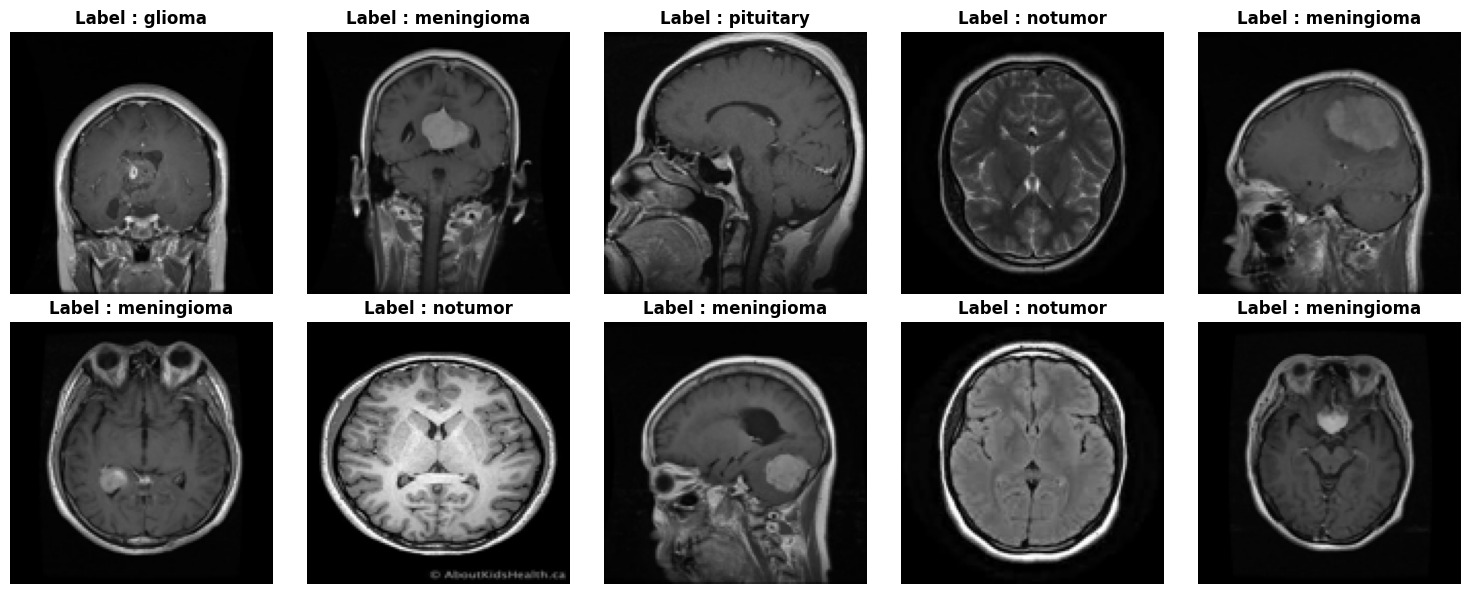

In [ ]:
# Selet random indices to plot 10 images
rand_idx = random.sample(range(len(train_path)), 10)

# Plot these 10 images
fig, axis = plt.subplots(2, 5, figsize = (15, 6))
axis = axis.ravel()                                                   # Ravel is used to conert any array to 1-d array

# Loop through Random Indices and Display Images
for i, idx in enumerate(rand_idx):
  ax = axis[i]
  img_path = train_path[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  # Display Image
  ax.imshow(img, cmap = 'gray')
  ax.axis('off')
  ax.set_title(f'Label : {train_label[idx]}', fontweight = 'semibold')

plt.tight_layout()
plt.show()

# ****Image Preprocessing (Helper Functions)****
1. **`Data Augumentation:`** It is regularization technique in deep learning, that artificially expands training dataset by creating modified, synthetic versions of existing data. Improves model generalization, robustness reduces overfitting. Common tech. include geometric reansfrmations (flips, rotations), color adjustment and noise mapping.

In [ ]:
# imag Augumentation Funct
def augment_img(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))           # if brightness > 1.0 ==> Dark, brightness < 1.0 ==> bright
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image) / 255.0
  return image

# Load Images and apply Augumentation
def open_img(paths):
  images = []
  for path in paths:
    img_pil = load_img(path, target_size = (IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_pil) # Convert PIL Image to numpy array
    img_aug = augment_img(img_array)
    images.append(img_aug)
  return np.array(images)

# Encode labels (Convert labels to integers)
def encoder(labels):
  unique_labels = os.listdir(train)
  encoded = [unique_labels.index(label) for label in labels]
  return encoded

# Data Generator for Batching (now yields individual samples for one full pass)
def datagen(train_path, train_label):
  for i in range(len(train_path)):
    single_path = train_path[i]
    single_image = open_img([single_path])[0] # Get the single image from the list returned by open_img
    single_label_str = train_label[i]
    single_label_encoded = encoder([single_label_str])[0] # Get the single encoded label
    yield single_image, single_label_encoded

## ****Transfer Learning :****
**Transfer Learning** is a technique in machine learning where model **trained on one task** is reused or adjusted to **solve a different, but related task.** Intead of training new model from scratch.

In [ ]:
# Model Architecture
IMG_SIZE = 128

with tf.device('/GPU:0'):
    base_model = VGG16(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

    # Freeze all layers of the VGG16 base model
    for layer in base_model.layers:
        layer.trainable = False

    # Set the last few layers of the VGG16 base model to be trainable
    base_model.layers[-2].trainable = True
    base_model.layers[-3].trainable = True
    base_model.layers[-4].trainable = True

    # Build the final model
    model = Sequential()
    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))  # Input layer
    model.add(base_model)  # Add VGG16 base model
    model.add(GlobalAvgPool2D())  # Flatten the output of the base model
    model.add(Dropout(0.3))  # Dropout layer for regularization
    model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
    model.add(Dropout(0.2))  # Dropout layer for regularization
    model.add(Dense(len(os.listdir(train)), activation='softmax'))  # Output layer with softmax activation

    # Compile the model
    model.compile(optimizer=AdamW(learning_rate=0.00009, weight_decay= 0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 32
epochs = 15
steps = len(train_path) // batch_size

# Create a tf.data.Dataset from the generator
# The generator now yields individual samples, so output_shapes reflect a single sample
train_dataset = tf.data.Dataset.from_generator(
    lambda: datagen(train_path, train_label), # datagen now yields single samples without an internal epochs loop
    output_types=(tf.float32, tf.int32),
    output_shapes=(tf.TensorShape([IMG_SIZE, IMG_SIZE, 3]), tf.TensorShape([])) # Shape for single image and single scalar label
).batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE) # Added .repeat() here to make the dataset repeatable

# Train Model
history = model.fit(
    train_dataset,
    steps_per_epoch = steps,
    epochs = epochs # Add epochs to model.fit instead of generator
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 137ms/step - loss: 0.5535 - sparse_categorical_accuracy: 0.7764
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - loss: 0.2821 - sparse_categorical_accuracy: 0.8945
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 140ms/step - loss: 0.2045 - sparse_categorical_accuracy: 0.9234
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 136ms/step - loss: 0.1654 - sparse_categorical_accuracy: 0.9391
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - loss: 0.1564 - sparse_categorical_accuracy: 0.9400
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - loss: 0.0931 - sparse_categorical_accuracy: 0.9671
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - loss: 0.0691 - sparse_categorical_accuracy: 0.9734
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - loss: 0.0487 - sparse_categorical_accuracy: 0.9829
Epoch 9/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - loss: 0.0379 - sparse_categorical_accuracy: 0.9871
Epoch 10/15
175/175 ━━━━━━━━

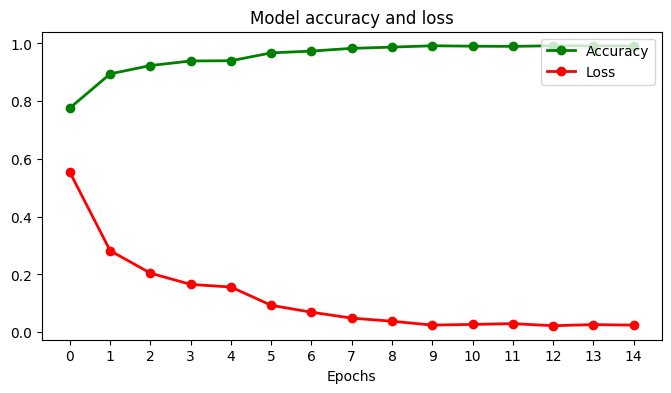

In [ ]:
plt.figure(figsize = (8, 4))
plt.plot(history.history['sparse_categorical_accuracy'], 'g-', linewidth = 2, marker = 'o')
plt.plot(history.history['loss'], 'r-', linewidth = 2, marker = 'o')
plt.title('Model accuracy and loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc = 'upper right', bbox_to_anchor = (1,1))
plt.show()

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import seaborn as sns

test_images = open_img(test_path)
test_label_enc = encoder(test_labels)

test_pred = model.predict(test_images)
print('Classification Report : ')
print(classification_report(test_label_enc, np.argmax(test_pred, axis= 1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       400
           1       0.94      1.00      0.97       400
           2       0.82      0.98      0.89       400
           3       0.98      0.74      0.84       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.92      1600
weighted avg       0.93      0.93      0.92      1600



Text(95.72222222222221, 0.5, 'Actual')

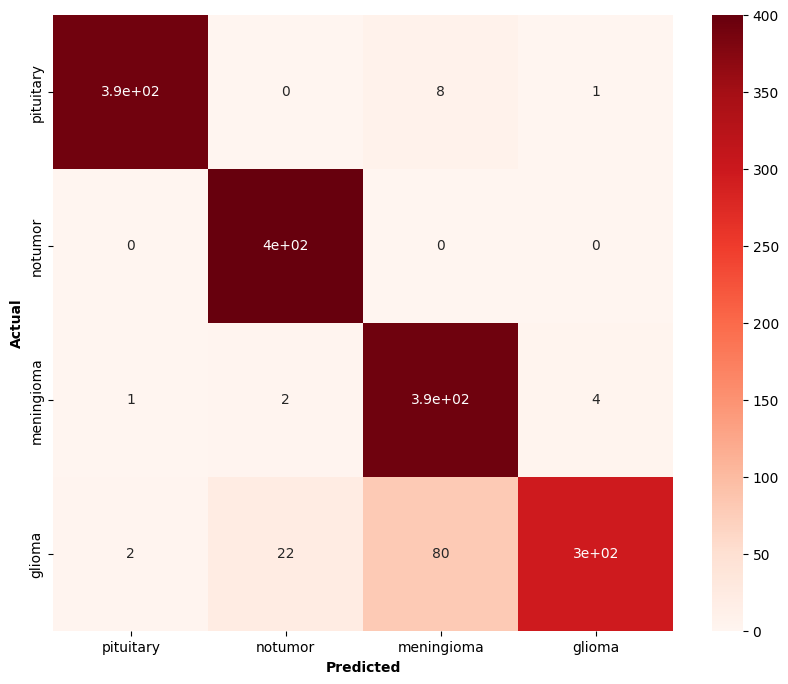

In [ ]:
cf = confusion_matrix(test_label_enc, np.argmax(test_pred, axis = 1))
plt.figure(figsize = (10, 8))
sns.heatmap(cf, annot = True, xticklabels = os.listdir(train), yticklabels = os.listdir(train), cmap = 'Reds')
plt.xlabel('Predicted', fontweight = 'semibold')
plt.ylabel('Actual', fontweight = 'semibold')

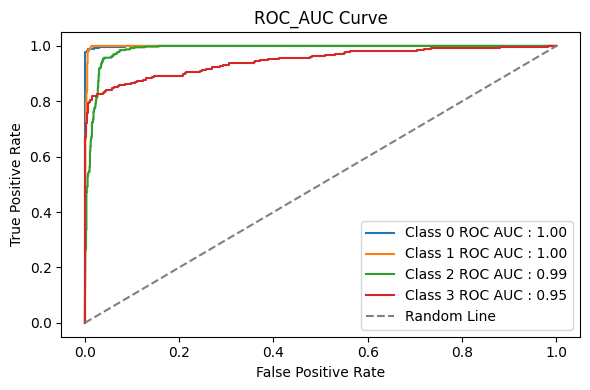

In [ ]:
# Roc Auc Curve

test_binarize = label_binarize(test_label_enc, classes = np.arange(len(os.listdir(train))))
test_pred_bin = test_pred

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(os.listdir(train))):
  fpr[i], tpr[i], _ = roc_curve(test_binarize[:, i], test_pred_bin[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize = (6, 4))
for i in range(len(os.listdir(train))):
  plt.plot(fpr[i], tpr[i], label = f'Class {i} ROC AUC : {roc_auc[i]:.2f}')
plt.plot([0,1], [0, 1], linestyle = '--', label = 'Random Line', color = 'gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# ****Save and Load the Model****

In [ ]:
# Save Model
model.save('Brain_Tumor.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load Trained Model
model = load_model('Brain_Tumor.h5')

# ****Mri Tumor Detection System****

In [ ]:
os.listdir(train)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [ ]:
from tensorflow.keras.preprocessing.image import img_to_array

class_labels = ['pituitary', 'notumor', 'meningioma', 'glioma']

def detect_and_display(image_path, model):
  try:
    # Load Image
    img = load_img(image_path, target_size= (128, 128))
    img_array = img_to_array(img)
    final_img = np.expand_dims(img_array, axis= 0)

    # Predictions
    prediction = model.predict(final_img)
    predicted_class = np.argmax(prediction)
    confidence_score = np.max(prediction, axis= 1)[0]

    # Determine the Class
    if class_labels[predicted_class] == 'notumor':
      result = 'No Tumor Detected'
    else:
      result = f'Tumor : {class_labels[predicted_class]}'

    # Display
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{result} (Confidence : {confidence_score*100:.2f}%)')
    plt.show()

  except Exception as e:
    print('Error processing the image : ', str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


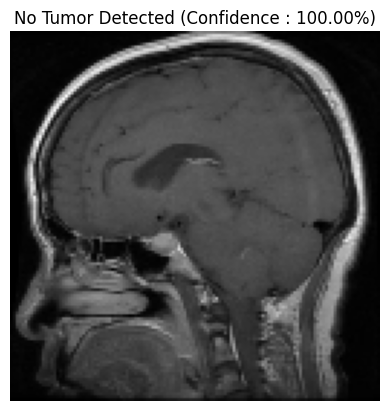

In [ ]:
image_path = '/content/Te-piTr_0003.jpg'
detect_and_display(image_path, model)